<a href="https://colab.research.google.com/github/itgirlhightech/Ada-Churn-Project/blob/main/Churn_Banco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

####ANALISE EXPLORATÓRIA DE DADOS

### 1. Importação de Bibliotecas e Carregamento dos Dados
Nesta etapa, preparamos o ambiente e visualizamos as primeiras linhas do dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carregando o dataset selecionado
df = pd.read_csv('/content/Churn_Modelling.csv')

# Visualização inicial
display(df.head())
display(df.info())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


None

### 2. Limpeza Inicial
Vamos verificar se existem valores nulos (NaN) ou duplicados que possam enviesar o modelo.

In [ ]:
# Verificando valores ausentes
print("Valores nulos por coluna:")
print(df.isnull().sum())

# Verificando duplicados
print(f"\nLinhas duplicadas: {df.duplicated().sum()}")

Valores nulos por coluna:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Linhas duplicadas: 0


### 3. Análise Estatística e Distribuição do Target
Vamos observar as medidas centrais e a proporção de Churn (Exited).

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


/tmp/ipykernel_18854/405310304.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=df, palette='viridis')


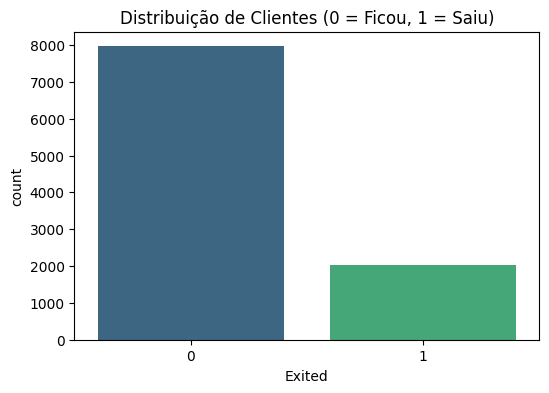

Proporção de Churn:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [ ]:
# Resumo estatístico das variáveis numéricas
display(df.describe())

# Verificando o balanceamento da variável alvo
plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=df, palette='viridis')
plt.title('Distribuição de Clientes (0 = Ficou, 1 = Saiu)')
plt.show()

print("Proporção de Churn:")
print(df['Exited'].value_counts(normalize=True) * 100)

### 4. Análise de Variáveis Categóricas e Correlação
Vamos investigar como variáveis como país e gênero impactam a decisão de sair do banco, além de analisar a correlação entre as variáveis numéricas.

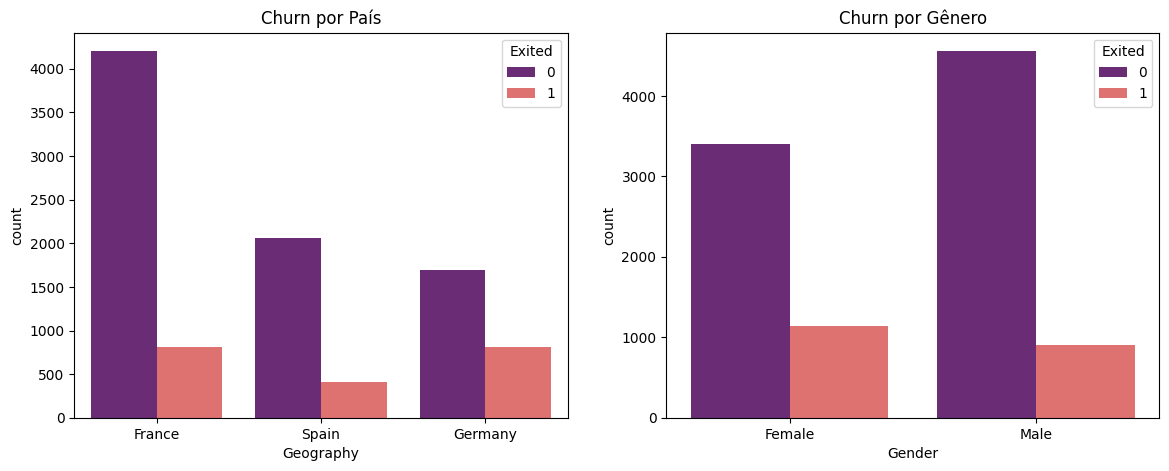

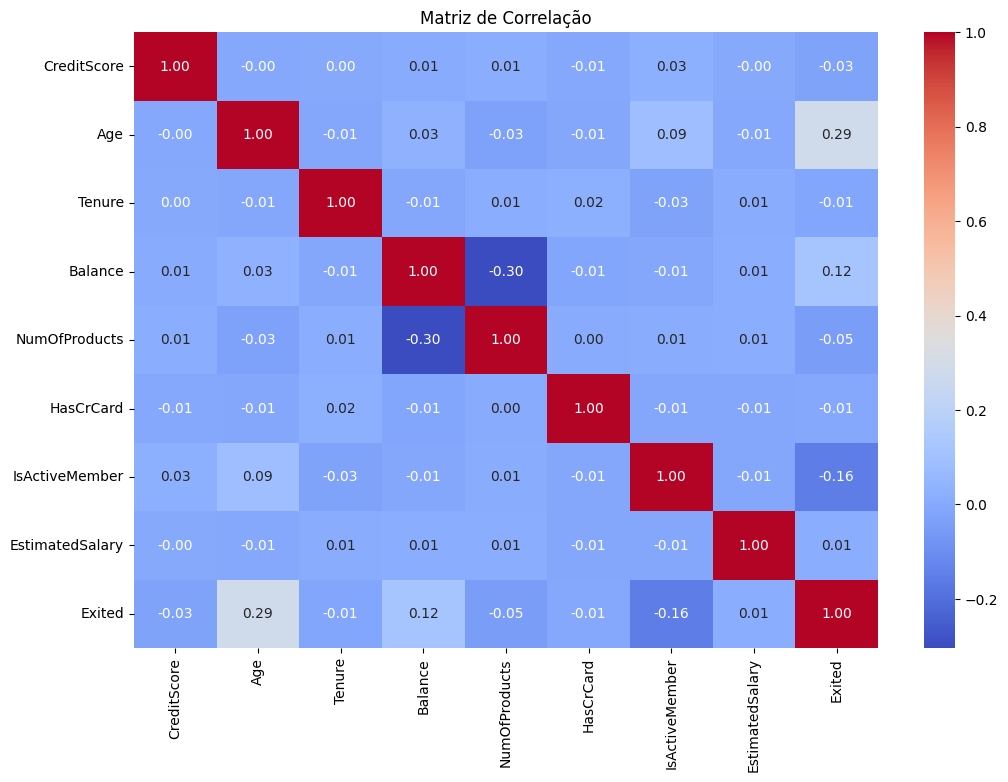

In [ ]:
# Comparação de Churn por Geografia e Gênero
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='Geography', hue='Exited', data=df, ax=ax[0], palette='magma')
ax[0].set_title('Churn por País')

sns.countplot(x='Gender', hue='Exited', data=df, ax=ax[1], palette='magma')
ax[1].set_title('Churn por Gênero')

plt.show()

# Mapa de Calor de Correlação
plt.figure(figsize=(12, 8))
# Selecionando apenas colunas numéricas para o heatmap
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['RowNumber', 'CustomerId'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()

### 3. Análise Estatística e Distribuição do Target
Vamos observar as medidas centrais e a proporção de Churn (Exited).

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


/tmp/ipykernel_18854/405310304.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=df, palette='viridis')


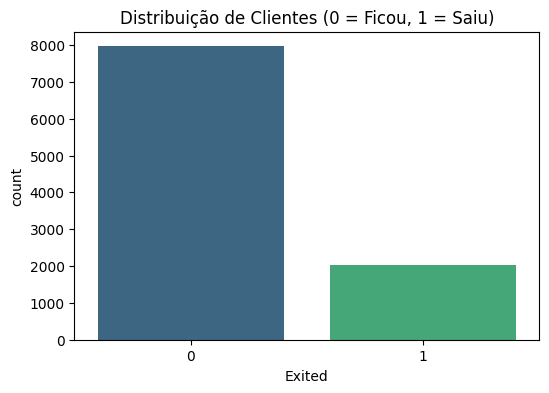

Proporção de Churn:
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [ ]:
# Resumo estatístico das variáveis numéricas
display(df.describe())

# Verificando o balanceamento da variável alvo
plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=df, palette='viridis')
plt.title('Distribuição de Clientes (0 = Ficou, 1 = Saiu)')
plt.show()

print("Proporção de Churn:")
print(df['Exited'].value_counts(normalize=True) * 100)